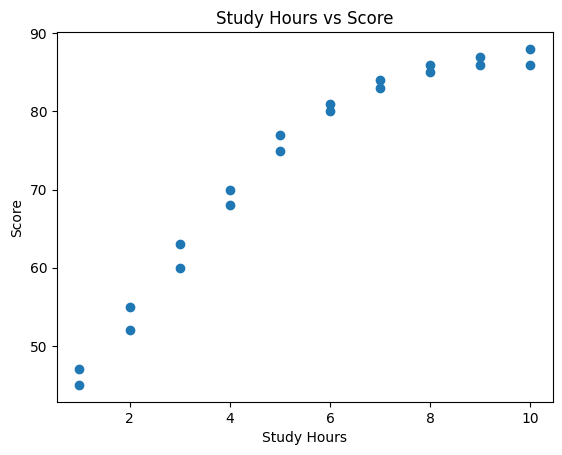

In [ ]:
# 변수	         의미
# study_hours	공부 시간
# focus_level	집중도
# score	        시험 점수

import pandas as pd

df = pd.DataFrame({
    "study_hours": [1,2,3,4,5,6,7,8,9,10,
                    1,2,3,4,5,6,7,8,9,10],

    "focus_level": [1,1,2,2,3,3,4,4,5,5,
                    1,2,2,3,3,4,4,5,5,5],

    "score": [
        45, 52, 60, 68, 75, 80, 83, 85, 86, 86,
        47, 55, 63, 70, 77, 81, 84, 86, 87, 88
    ]
})

# 공부시간 vs 점수
import matplotlib.pyplot as plt

plt.scatter(df["study_hours"], df["score"])
plt.title("Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

In [3]:
# 위 데이터는 선형이긴 하지만, y=ax+b 그래프로 설명하기엔 설득력이 좀 떨어져 보인다.
# 약간의 곡선이 있다. 그래서 x^2으로 피처를 제곱해서 그려보자
# 다항회귀, 회귀라고 합니다. 연속된 값을 예측하는 모델
# 즉, 피처를 제곱, 3제곱해서 연속 값을 예측해보자

# 모델 개발 순서
# 개발 모델 정의 : 성적 결과를 예측하는 모델 만들기
# 데이터 로드 > 전처리 > 피처의 상관관계 (산점도, 파이플롯, 히트맵)
# > 모델을 선택(다중선형회귀, 다항선형회귀 둘 중 하나 선택)
# > 데이터셋 > 모델생성 > 학습 > 평가

# 지금부터는 자세한 내용은 생략하고 진행

In [18]:
# 데이터 셋
X = df[['study_hours','focus_level']] ## 문제 데이터
y = df['score']

print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split

# 앞의 4개가 변수입니다. 아무거나 해도 됩니다. 그러나
# 실무에서는 다음과 같은 네이밍을 준수합니다.
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(20, 2)
(20,)
(16, 2)
(4, 2)


In [19]:
# 모델을 만든다
# 오늘 선택한 모델은 곡선을 설명해야 한다. 그래서 다항회귀모델을 사용!
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 차수가 2인 모델을 만들어 봅니다.
model = make_pipeline(
    PolynomialFeatures(degree=2), # X^2으로 만들겠다.
    LinearRegression()
)

# 공식을 외울 필요는 없지만, 이해는 꼭 필요하다. 궁금하면 재미나이가 만들어 달라고 해도 괜찮다.
# 피처 1개, degree 2라면 > y = ax^2 + bx + c
# 피처 2개, degree 2라면 > y = ax1^2 + bX1X2 + cX2^2 + dX1 + eX2 + f

In [20]:
## 모델 학습
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [27]:
# 기울기랑 절편 확인해보자 (참고용)

lr = model.named_steps['linearregression']
print("계수",lr.coef_)
print("절편",lr.intercept_)

계수 [ 0.          8.57099855  4.87025119 -0.86132448  1.60006228 -2.02117501]
절편 33.561760431804274


In [32]:
# 모델 평가 회귀평가 : mse, rmse, r2
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

y_pred = model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(y_pred)
print(mse)
print(rmse)
print(r2)

[45.72057297 84.82935437 79.52376998 53.30766037]
1.4447168268529493
1.2019637377445915
0.9954208658419875


In [35]:
## 새로운 데이터 예측
new_data=pd.DataFrame({
    "study_hours":[3,7,9],
    "focus_level":[2,4,5]
})
pred=model.predict(new_data)
pred

array([62.77901183, 83.29779946, 86.75814823])

In [ ]:
## 데이터를 보고 선행회귀로 예측이 가능하다고 판단되면
## 다중선형회귀나 다항선형회귀로 모델을 만들고 평가할 수 있다.